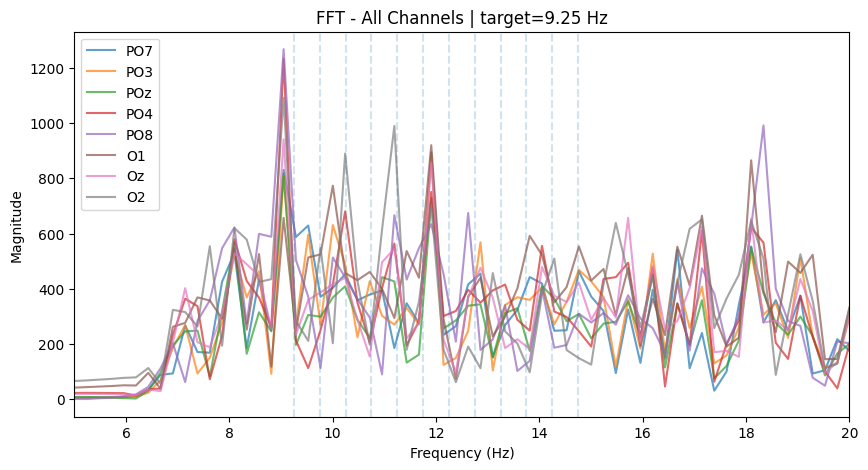

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
from scipy.io import loadmat
import mne

# -------------------------
# Settings
# -------------------------
DATA_PATH = "../data/s1.mat"   # change if needed
FS = 256
STIM_ONSET = 39
CH_NAMES = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]

TARGET_FREQS = np.array([
    9.25, 11.25, 13.25,
    9.75, 11.75, 13.75,
    10.25, 12.25, 14.25,
    10.75, 12.75, 14.75
])

# -------------------------
# Load one trial
# -------------------------
mat = loadmat(DATA_PATH)
eeg = mat["eeg"]   # shape: (12, 8, 1114, 15)

target_idx = 0
trial_idx = 0

trial = eeg[target_idx, :, STIM_ONSET:, trial_idx]   # shape: (8, samples)

# -------------------------
# MNE filtering
# -------------------------
info = mne.create_info(ch_names=CH_NAMES, sfreq=FS, ch_types="eeg")
raw = mne.io.RawArray(trial, info, verbose=False)
raw.filter(8.0, 40.0, verbose=False)
trial_filt = raw.get_data()

# -------------------------
# FFT of all channels
# -------------------------

plt.figure(figsize=(10, 5))

for ch_idx, ch_name in enumerate(CH_NAMES):
    x = trial_filt[ch_idx]

    freqs = rfftfreq(len(x), d=1/FS)
    spectrum = np.abs(rfft(x))

    plt.plot(freqs, spectrum, label=ch_name, alpha=0.7)

plt.xlim(5, 20)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"FFT - All Channels | target={TARGET_FREQS[target_idx]} Hz")

# show target frequencies
for f in TARGET_FREQS:
    plt.axvline(f, linestyle="--", alpha=0.2)

plt.legend()
plt.show()